# Return Distribution Analysis
For our prices to be GBM, our log prices must be Brownian motion (BM). This means that the difference series (i.e. log returns) must be normally distributed, not autocorrelated, and homoskedastic in time. This notebook focuses on evaluating the validity of these assumptions for our chosen stock, PG. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, jarque_bera, shapiro, probplot, kstest
from statsmodels.distributions.empirical_distribution import ECDF

In [2]:
df = pd.read_csv("../data/pg_daily.csv")

In [3]:
def pvalue_handler(p: float, test_name: str, trait: str, alpha: float = 0.05):
    print(test_name, " p-value:", p)

    if p >= alpha:
        print("No evidence to reject the null - the data may be ", trait)
    else:
        print("Reject the null - the data is NOT ", trait)

## Normality of Log Returns

There are various tests we may use for testing for normality. The most well known are Jarque-Bera (JB), Shapiro-Wilk (SW), and Kolmogorov-Smirnov (KS). Each of these have as their null hypothesis that the data was generated from a normal distribution. This means that in each case we are looking for lack of evidence to reject the null. This carries the caveat that we can never truly conclude that our data is normally distributed using these tests, only confidently conclude that it is not, if the tests dail.

To somewhat mitigate this, we will run all three of the tests mentioned above, to look for any evidence that our data is not normally distributed. 

#### 1. The Jarque-Bera Test

The JB test uses a test statistic that is based on the sample skew and kurtosis that is $\chi^2_2$ distributed under the null hypothesis that the skew and kurtosis of the underlying distribution are 0 and 3 respectively (the quantities for the normal distribution). 

In [4]:
_, jb_pvalue = jarque_bera(df['log_return'].dropna())

In [5]:
pvalue_handler(jb_pvalue, "Jarque-Bera", "normally distributed")

Jarque-Bera  p-value: 0.0
Reject the null - the data is NOT  normally distributed


#### 2. The Shapiro-Wilk Test

The SW test essentially compares the sample percentiles to the normal distribution percentiles, similar to a Q-Q plot. Under the null hypothesis this plot should cluster around the "$y=x$" line. 

In [6]:
mu_hat = df["log_return"].mean()
sigma_hat = df["log_return"].std()

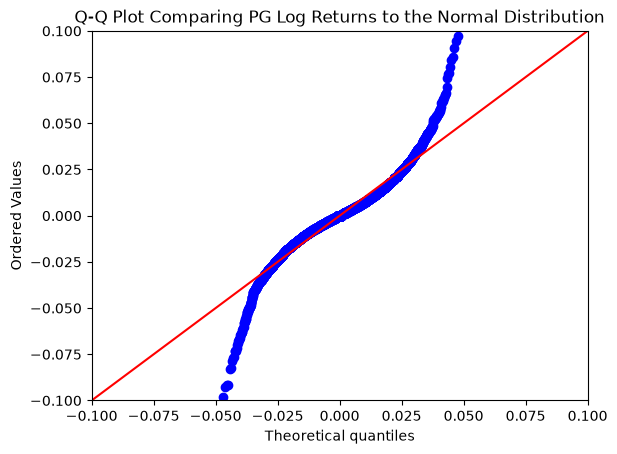

In [7]:
probplot(df['log_return'], dist="norm", sparams=(mu_hat, sigma_hat), plot=plt)
plt.axline((0, 0), slope=1, color='red')

plt.title("Q-Q Plot Comparing PG Log Returns to the Normal Distribution")
plt.xlim(-0.1, 0.1)
plt.ylim(-0.1, 0.1)

plt.show()

In [8]:
_, sw_pvalue = shapiro(df['log_return'].dropna())

/Users/benjones/Projects/quant-finance/equity-random-walk-exploration/.venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 16282.
  res = hypotest_fun_out(*samples, **kwds)


In [9]:
pvalue_handler(sw_pvalue, "Shapiro-Wilk", "normally distributed")

Shapiro-Wilk  p-value: 1.1323151624931547e-74
Reject the null - the data is NOT  normally distributed


#### 3. The Kolmogorov-Smirnov Test

The KS test is a more general distribution test that compares the CDF plot of any distribution (in our case normal) to the empirical CDF plot for the data.

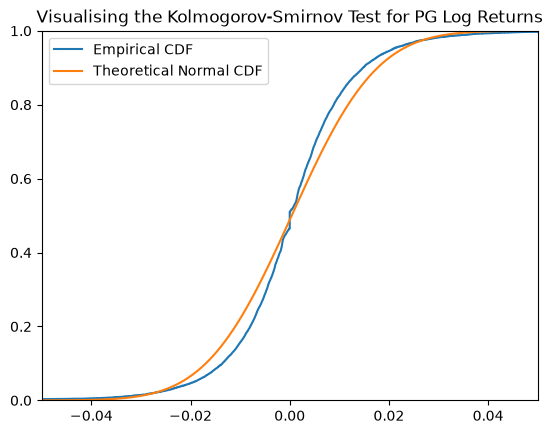

In [10]:
ecdf = ECDF(df['log_return'].dropna())
x = np.sort(df['log_return'].dropna())

plt.step(ecdf.x, ecdf.y, label='Empirical CDF')
plt.plot(x, norm.cdf(x, loc=mu_hat, scale=sigma_hat), label='Theoretical Normal CDF')
plt.xlim(-0.05, 0.05)
plt.ylim(0, 1)
plt.title("Visualising the Kolmogorov-Smirnov Test for PG Log Returns")
plt.legend()

In [11]:
_, ks_pvalue = kstest(df['log_return'].dropna(), norm(loc=mu_hat, scale=sigma_hat).cdf)

In [12]:
pvalue_handler(ks_pvalue, "Kolmogorov-Smirnov", "normally distributed")

Kolmogorov-Smirnov  p-value: 1.0087099007912637e-67
Reject the null - the data is NOT  normally distributed


#### 4. The Eye Test

Lastly, we will apply the not so rigorous "eye test" by plotting the density of our data against the PDF of a normal distribution with its mean and standard deviation as the sample mean and sample standard deviation respectively.

In [13]:
x = np.linspace(mu_hat - 4*sigma_hat, mu_hat + 4*sigma_hat, 1000)
y = norm.pdf(x, loc=mu_hat, scale=sigma_hat)

In [14]:
sigma_hat

np.float64(0.013511087448842836)

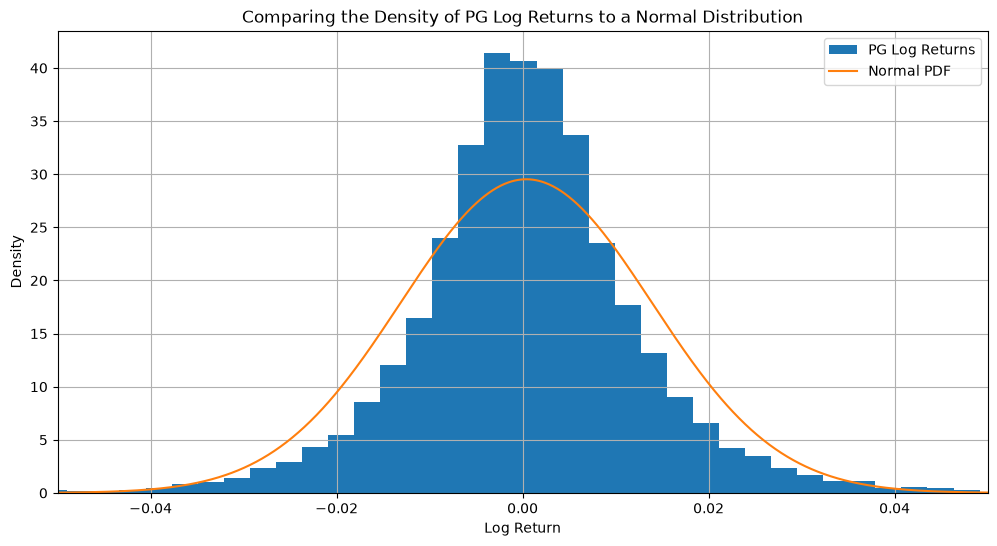

In [15]:
plt.figure(figsize=(12, 6))

df["log_return"].hist(bins=200, density=True, label="PG Log Returns")
plt.plot(x, y, label=f"Normal PDF")

plt.xlim(-0.05, 0.05)
plt.title("Comparing the Density of PG Log Returns to a Normal Distribution")
plt.xlabel("Log Return")
plt.ylabel("Density")
plt.legend()
plt.show()

All three of our tests provided evidence to reject the null and conclude that log returns are not normally distributed. This is in line with a well-documented stylised fact of log returns, that they have fatter tails than normal distributions (Cont, 2001, [Empirical Properties of Asset Returns: Stylized Facts and Statistical Issues](https://doi.org/10.1080/713665670)). In future work, there are interesting opportunities to model log returns more accurately, such as using [Merton's Jump Diffusion model (1976)](https://doi.org/10.1016/0304-405X(76)90022-2), however this is beyond the scope of this project.

Given the fact that this is a well-documented limitation, we will push forward with our investigation. Indeed, GBM may still prove to be useful even if its assumptions do not hold perfectly.